<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Integracion-de-prospectiva-y-datos/blob/main/Integracion_Multidimensional_Fintech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Caso de Estudio: Integración Multidimensional — Sector Fintech**

Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a sus solicitantes de crédito. Para ello se llevará a cabo un proceso de **integración multidimensional** de los datos a **5 sucursales**, utilizando el método **K-Medoids (Integración Dinámica Multidimensional)**.

Las variables utilizadas para la integración son las variables numéricas:
- **Edad**, **Hijos**, **Personas a Cargo (Perscargo)**, **Estrato**
- **Ingresos**, **Egresos**, **Monto del crédito (EAD)**, **Plazo**, **Cuota**

Las variables cualitativas (Sexo, Estado Civil, Tipo de Vivienda, etc.) **no entran** en la integración multidimensional; se usan únicamente para construir los perfiles descriptivos de cada sucursal.

### 0. Se cargan las librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Carga de los datos de trabajo

In [ ]:
nxl = '/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/4. SolicitantesCrédito(USD)_Municipios.xlsx'
xls = pd.ExcelFile(nxl)  # Trae todas las hojas del archivo de Excel
print(xls.sheet_names)

# Se procede con la integración de todos los datos en una sola hoja
XDB = pd.DataFrame()

for sheet in xls.sheet_names:
    print(sheet)
    df = pd.read_excel(xls, sheet_name=sheet)
    XDB = pd.concat([XDB, df], ignore_index=True)

# Ofuscamos los datos (desordenamos para evitar sesgos por orden)
XDB = XDB.sample(frac=1, random_state=42).reset_index(drop=True)
XDB = XDB.dropna()

display(XDB.head())
print('Total de solicitantes:', len(XDB))

['Base Datos Municipios']
Base Datos Municipios


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,6556,63,NR,Unión Libre,1,1,1,3,Bachiller,Ninguno,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.233305,474.284668,0.473965,94.814667,Caldas
1,239,31,Mujer,Soltero,0,1,1,2,Tecnólogo,Indefinido,...,Buena Experiencia CFB,Fondo de Garantia,Prop.sin Hipoteca,Con Experiencia sin Mora,0,0.254857,322.984283,0.386951,-59.363306,Caldas
2,226,61,NR,Casado,7,3,3,2,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.089151,619.955383,0.156131,175.430444,Sabaneta
3,8017,42,Mujer,Soltero,2,1,1,3,Tecnólogo,Fijo,...,Buena Experiencia CFB,Libranza Establecida,Sin Patrimonio,Una mora 60 Dìas,0,0.157716,486.018250,0.292610,265.696222,Caldas
4,3334,32,Mujer,Soltero,1,1,1,4,Bachiller,Indefinido,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.089574,517.180481,0.155736,406.870611,Itagüí


Total de solicitantes: 5842


### 2. Se crean las semillas de integración

**Análisis de resultados:** Los cinco primeros registros de la base de datos se convierten en las **semillas de integración** para el modelo K-Medoids. Estas semillas representan los centroides iniciales de las 5 sucursales.

In [ ]:
vars_num = ['Edad', 'Hijos', 'Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']

XDB2 = XDB[vars_num]  # DataFrame secundario solo con variables numéricas

XC = np.array(XDB2.iloc[0:5, :])   # Semillas — primeros 5 solicitantes (XC = CENTROIDES)
XD = np.array(XDB2.iloc[:, :])     # Todos los datos
nc = np.zeros((len(XD), 1))        # Vector de asignación de cluster

print('Semillas iniciales (primeros 5 solicitantes):')
dfxc_ini = pd.DataFrame(XC, columns=vars_num)
dfxc_ini.index = ['Sucursal 1', 'Sucursal 2', 'Sucursal 3', 'Sucursal 4', 'Sucursal 5']
display(dfxc_ini)

Semillas iniciales (primeros 5 solicitantes):


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,63.0,1.0,1.0,3.0,176.33400,81.519333,172.442108,48.0,5.065487
Sucursal 2,31.0,0.0,1.0,2.0,315.82025,375.183556,137.735049,36.0,4.979452
Sucursal 3,61.0,7.0,3.0,2.0,915.54600,740.115556,723.590181,48.0,21.255461
Sucursal 4,42.0,2.0,1.0,3.0,483.95200,218.255778,501.956390,48.0,14.744969
Sucursal 5,32.0,1.0,1.0,4.0,817.09350,410.222889,819.789060,36.0,29.637338


### 3. Se procede con la integración dinámica multidimensional (K-Medoids)

Para cada solicitante se asigna al cluster más cercano.

In [ ]:
# Se procede con la integración
for k in range(len(XD)):
    Xind = XD[k, ]  # Individuo actual (solicitante k) — XIND = INDIVIDUO

    # Distancia del individuo respecto a cada centroide
    denominador = np.where(XC == 0, 0.0001, XC)
    m1 = np.sum(((XC - Xind) / denominador)**2, axis=1)
    nc[k] = np.argmin(m1)           # Cluster más cercano al solicitante k
    cluster = int(np.argmin(m1))
    XC[cluster, ] = (XC[cluster, ] + Xind) / 2  # Actualización dinámica del centroide

# Se muestran los centroides finales
dfxc = pd.DataFrame(XC, columns=vars_num)
dfxc.index = ['Sucursal 1', 'Sucursal 2', 'Sucursal 3', 'Sucursal 4', 'Sucursal 5']
print('Centroides finales de cada sucursal:')
display(dfxc)

# ¿Cuántos solicitantes quedaron por sucursal?
ND = []
for j in range(5):
    nd = len(np.where(nc[:, ] == j)[0])
    ND.append(nd)
    print(f'El número de solicitantes en la Sucursal {j+1} es: {nd}')

dfxc['N_Solicitantes'] = ND

Centroides finales de cada sucursal:


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,38.833495,1.784844e-25,1.880791e-37,2.058571,219.065456,157.708670,219.186553,32.182440,8.564546
Sucursal 2,45.659730,0.000000e+00,5.949119e-09,3.122924,7.542339,5.809386,4.073477,33.355430,0.170723
Sucursal 3,27.172960,1.539585e-01,1.563630e+00,2.045467,490.902385,514.509391,333.741282,23.138103,30.648833
Sucursal 4,62.557573,8.951575e-29,5.317518e-64,1.632118,37.964387,38.349475,25.220723,23.568435,1.269565
Sucursal 5,56.190774,9.466331e-30,1.577722e-30,3.390450,34.403579,39.667950,16.840429,34.290079,0.632009


El número de solicitantes en la Sucursal 1 es: 123
El número de solicitantes en la Sucursal 2 es: 44
El número de solicitantes en la Sucursal 3 es: 5359
El número de solicitantes en la Sucursal 4 es: 215
El número de solicitantes en la Sucursal 5 es: 101


### 4. Se determinan los perfiles de los solicitantes por sucursal

Para cada sucursal se calcula la media de todas las variables numéricas, los municipios de procedencia y el porcentaje de preaprobación / prenegación.

In [ ]:
# Base de datos solo con variables numéricas
XDB_num = XDB[vars_num]
PRC = np.zeros((5, len(vars_num)))  # 5 Sucursales — 9 variables (perfiles)

for j in range(5):
    filas = np.where(nc == j)[0]  # Filas de los solicitantes de la sucursal j
    df2 = XDB_num.iloc[filas, ]
    df3 = pd.DataFrame(np.mean(df2, axis=0))
    df3.columns = ['Sucursal ' + str(j + 1)]
    display(df3.T)

    # Municipios de procedencia
    municipios = XDB.iloc[filas]['Municipio'].value_counts()
    print(f'Municipios de la Sucursal {j+1}:', municipios.to_dict())

    # Porcentaje de preaprobación y prenegación
    n_preaprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_prenegados   = len(np.where(XDB.iloc[filas]['PreApr'] == 0)[0])
    total          = n_preaprobados + n_prenegados
    print(f'El porcentaje de preaprobados de la Sucursal {j+1} es: {n_preaprobados/total*100:.1f}%')
    print(f'El porcentaje de prenegados de la Sucursal {j+1} es: {n_prenegados/total*100:.1f}%')

    PRC[j, ] = np.mean(df2, axis=0)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,41.495935,0.357724,0.00813,2.682927,349.174171,339.79271,215.510179,33.609756,11.938256


Municipios de la Sucursal 1: {'Caldas': 83, 'Itagüí': 15, 'Sabaneta': 13, 'Bello': 9, 'Medellín': 2, 'Envigado': 1}
El porcentaje de preaprobados de la Sucursal 1 es: 18.7%
El porcentaje de prenegados de la Sucursal 1 es: 81.3%


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 2,41.295455,0.0,0.522727,2.681818,387.401193,330.72996,294.438032,30.613636,12.701485


Municipios de la Sucursal 2: {'Caldas': 29, 'Itagüí': 5, 'Bello': 5, 'Sabaneta': 4, 'Medellín': 1}
El porcentaje de preaprobados de la Sucursal 2 es: 25.0%
El porcentaje de prenegados de la Sucursal 2 es: 75.0%


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 3,40.949058,1.125583,0.917522,2.920694,745.49244,663.557828,546.287401,32.548237,30.908056


Municipios de la Sucursal 3: {'Sabaneta': 1715, 'Caldas': 1626, 'Bello': 987, 'Itagüí': 534, 'Medellín': 422, 'Envigado': 75}
El porcentaje de preaprobados de la Sucursal 3 es: 50.9%
El porcentaje de prenegados de la Sucursal 3 es: 49.1%


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 4,42.851163,0.911628,0.018605,2.84186,592.370659,530.833002,441.097618,32.372093,19.937604


Municipios de la Sucursal 4: {'Caldas': 101, 'Sabaneta': 52, 'Bello': 28, 'Itagüí': 18, 'Medellín': 16}
El porcentaje de preaprobados de la Sucursal 4 es: 38.6%
El porcentaje de prenegados de la Sucursal 4 es: 61.4%


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 5,41.633663,0.039604,0.019802,3.069307,629.740757,563.970055,462.672195,33.207921,28.962072


Municipios de la Sucursal 5: {'Caldas': 39, 'Sabaneta': 20, 'Bello': 18, 'Itagüí': 16, 'Medellín': 7, 'Envigado': 1}
El porcentaje de preaprobados de la Sucursal 5 es: 37.6%
El porcentaje de prenegados de la Sucursal 5 es: 62.4%


### 5. Tabla resumen por sucursal (municipios y preaprobación)

In [ ]:
resumen = []
for j in range(5):
    filas = np.where(nc == j)[0]
    municipios   = XDB.iloc[filas]['Municipio'].value_counts().to_dict()
    n_preaprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_prenegados   = len(np.where(XDB.iloc[filas]['PreApr'] == 0)[0])
    total          = n_preaprobados + n_prenegados
    resumen.append({
        'Sucursal'        : f'Sucursal {j+1}',
        'N_Solicitantes'  : total,
        'Municipios'      : ', '.join([f'{m}({c})' for m, c in municipios.items()]),
        '% Preaprobados'  : f'{n_preaprobados/total*100:.1f}%',
        '% Prenegados'    : f'{n_prenegados/total*100:.1f}%'
    })

df_resumen = pd.DataFrame(resumen)
df_resumen = df_resumen.set_index('Sucursal')
display(df_resumen)

,N_Solicitantes,Municipios,% Preaprobados,% Prenegados
Sucursal,,,,
Sucursal 1,123,"Caldas(83), Itagüí(15), Sabaneta(13), Bello(9)...",18.7%,81.3%
Sucursal 2,44,"Caldas(29), Itagüí(5), Bello(5), Sabaneta(4), ...",25.0%,75.0%
Sucursal 3,5359,"Sabaneta(1715), Caldas(1626), Bello(987), Itag...",50.9%,49.1%
Sucursal 4,215,"Caldas(101), Sabaneta(52), Bello(28), Itagüí(1...",38.6%,61.4%
Sucursal 5,101,"Caldas(39), Sabaneta(20), Bello(18), Itagüí(16...",37.6%,62.4%


### 6. Gráfico de Araña — Perfiles multidimensionales por sucursal

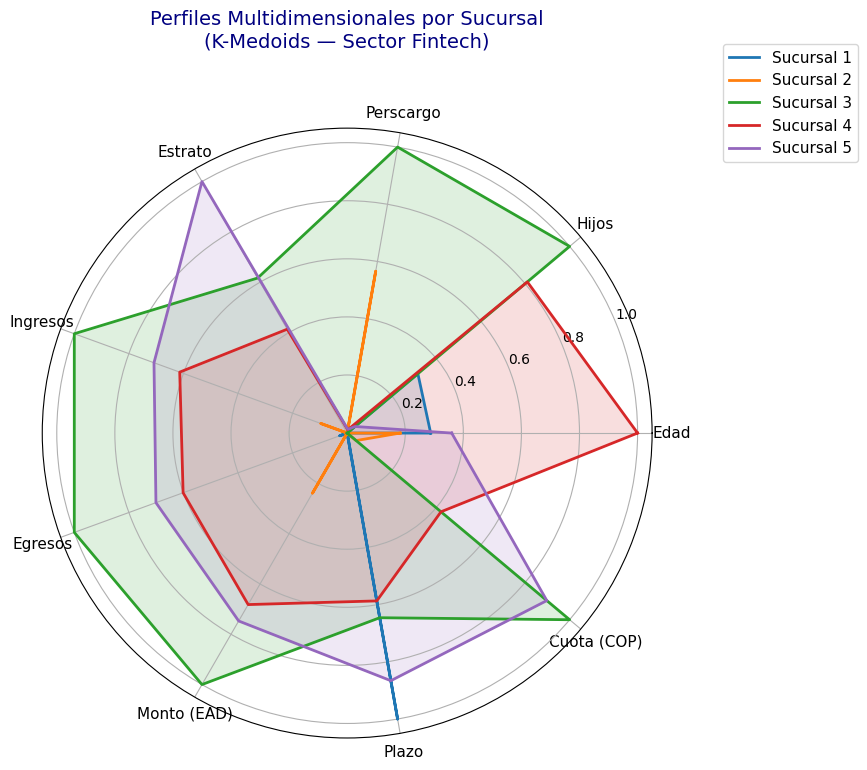

Gráfico guardado como radar_sucursales.png


In [ ]:
# Construimos el DataFrame de perfiles
cluster_profiles_list = []
for j in range(5):
    filas = np.where(nc == j)[0]
    df_cluster = XDB_num.iloc[filas, ]
    cluster_mean = np.mean(df_cluster, axis=0)
    cluster_profiles_list.append(
        pd.DataFrame(cluster_mean).T.set_index(pd.Index(['Sucursal ' + str(j + 1)]))
    )

profiles_df = pd.concat(cluster_profiles_list)

# Normalización min-max para visualización en radar (escala 0-1)
profiles_df_normalized = profiles_df.copy()
for col in profiles_df.columns:
    min_val = profiles_df[col].min()
    max_val = profiles_df[col].max()
    if (max_val - min_val) != 0:
        profiles_df_normalized[col] = (profiles_df[col] - min_val) / (max_val - min_val)
    else:
        profiles_df_normalized[col] = 0.5

# Configuración del gráfico de araña
labels   = list(profiles_df_normalized.columns)
num_vars = len(labels)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]  # Cierra el polígono

colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, sucursal in enumerate(profiles_df_normalized.index):
    values  = profiles_df_normalized.loc[sucursal].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=sucursal, color=colores[i])
    ax.fill(angles, values, alpha=0.15, color=colores[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Perfiles Multidimensionales por Sucursal\n(K-Medoids — Sector Fintech)',
             size=14, color='navy', y=1.12)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.savefig('radar_sucursales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como radar_sucursales.png')

### 7. Gráfico de barras — Distribución de solicitantes y preaprobación por sucursal

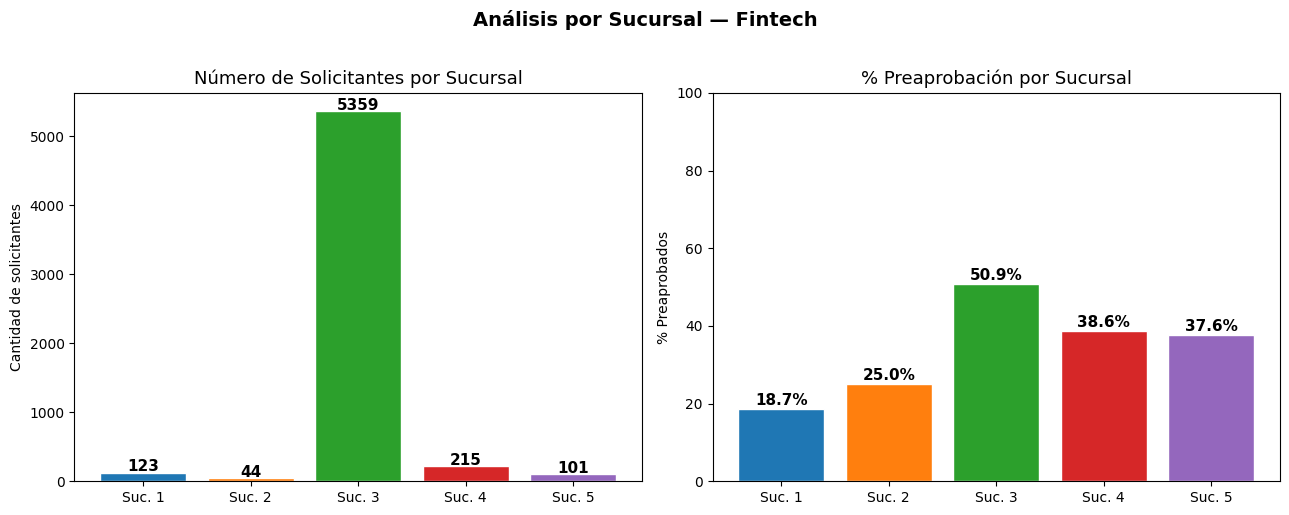

Gráfico guardado como barras_sucursales.png


In [ ]:
sucursales     = [f'Suc. {j+1}' for j in range(5)]
n_solicitantes = []
pct_preaprobados = []

for j in range(5):
    filas = np.where(nc == j)[0]
    total = len(filas)
    n_preaprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_solicitantes.append(total)
    pct_preaprobados.append(n_preaprobados / total * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Solicitantes por sucursal
axes[0].bar(sucursales, n_solicitantes, color=colores, edgecolor='white')
axes[0].set_title('Número de Solicitantes por Sucursal', fontsize=13)
axes[0].set_ylabel('Cantidad de solicitantes')
for i, v in enumerate(n_solicitantes):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11, fontweight='bold')

# Porcentaje de preaprobación
axes[1].bar(sucursales, pct_preaprobados, color=colores, edgecolor='white')
axes[1].set_title('% Preaprobación por Sucursal', fontsize=13)
axes[1].set_ylabel('% Preaprobados')
axes[1].set_ylim(0, 100)
for i, v in enumerate(pct_preaprobados):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Análisis por Sucursal — Fintech', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('barras_sucursales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como barras_sucursales.png')

#**Analisis de resultados:**

Para realizar la integracios de datos de los individuos para que sean atendidos solo en cinco sucursales tomamos 5 centrides que fueron los 5 primeros individuos de nuestro dataset. Al calcular los usuarios que eran más a fin con cada centroide vemos que:

*   Sucursal 1: 123 individuos. Datos respectos a los promedios son > Ingresos y egresos de sprx 340, monto de 215, plazo de 33 y cuota de 11
*   Sucursal 2: 44 individuos.  Datos relevantes respecto a los promedios son> que tienen 0 hijos, ingresos y egresos de aprox 380, un monto de 294, una cuota de 13.
*   Sucursal 3: 5359 individuos. Datos relevantes respecto a los promedios son > 1 hijo o más, 1 persona a cargo, 745 de ingresos, y 663 de egresos, monto de 546 y cuota de 30.
*   Sucursal 4: 215 individuos. Datos relevantes respecto a los promedios son > ingresos de 592, egresos de 530, monto de 442, cuota de 19.
*   Sucursal 5: 101 individuos. Datos relevantes respecto a los promedios son > Ingresos de 629, egreso de 563, monto de 462, cuota de 28.

Para todos el promedio de edad es de al rededor 41, tienen de 0-1 hijo, hay 0-1 persona a cargo, son estrato 2-3, y el plazo es de al rededor 31 días.

Conclusiones:

- La Sucursal 3 concentra el 91.7% de todos los solicitantes (5.359 de 5.842). Eso indica que la gran mayoría de clientes tiene un perfil muy similar entre sí, y las otras 4 sucursales capturan perfiles atípicos o extremos que se alejaron del centroide principal.
- Las sucursales 1 y 2 agrupan clientes de bajos ingresos (alrededor de 340-380 USD), montos pequeños y cuotas bajas.
- A mayores ingresos, mayor porcentaje de preaprobación. Pues la que mayor tiene porcentaje de preaprobacion es la sucursal 3 donde hay un promedio de ingresos de 745. En el resto de la preaprobacion es muy baja ( 1 -18%, 2- 25%, 4- 38%, 5- 37%)






